In [699]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [700]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

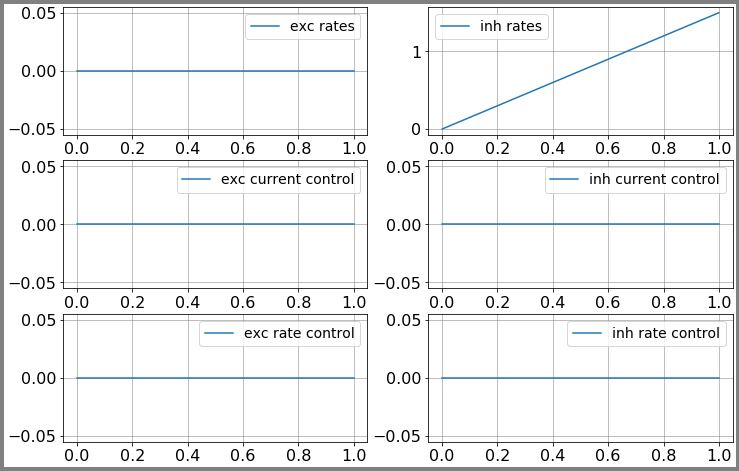

[[0. 0.]]


In [701]:
aln = RateModel()

aln.params.dt = 1.
aln.params['duration'] = 1.
control0 = aln.getZeroControl()
target = aln.getZeroTarget()
#control0 = step_control(maxI_ = 1.)

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.sigmae_ext = 0.

#aln.params.c_gl = 1.
#aln.params.Ke_gl = 1.
#aln.params.tau_se = 1.
#aln.params.Jee_max = 1.
#aln.params.C = 1.
#aln.params.gL = 1.
#aln.params.cee = 1.
#aln.params.Ke = 1.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroFullState()
plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

for i in range(len(state_vars)):
    state[:,i,:] = aln.state[state_vars[i]]

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]
        
high_state_vars[5] = 0.
high_state_vars[0] = 0.


print(aln.state["mufe"])

In [702]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                    

In [703]:
tol = 1e-18

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

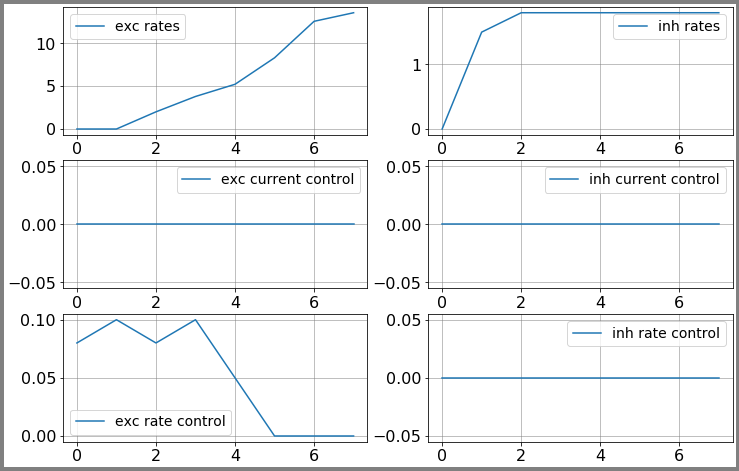

[[0.         0.24691358 0.46700198 0.5857971  0.69986598 0.72664543
  0.71272527 0.71271193]]
[[0.         1.2345679  2.77777778 4.11122756 5.84176509 6.87085115
  7.28079705 7.90081192]]
[[0.         2.00235814 3.19338492 3.4791779  5.14310264 7.69632519
  6.93075599 7.02850025]]


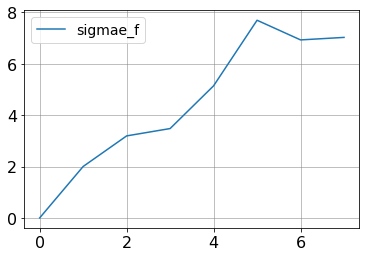

In [827]:
dur = 7.
dur_pre = 0.
dur_post = 0.
aln.params.duration = dur

control_ind = 2
control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
control0[0,control_ind,0] =  0.08
control0[0,control_ind,1] =  0.1
control0[0,control_ind,2] =  0.08
control0[0,control_ind,3] = 0.1
control0[0,control_ind,4] = 0.05
#control0[0,control_ind,:] = [0.08044293, 0.07931774, 0.05732154, 0.00748632, 0.07283936, 0.00502723, 0.00554333, 0.04001615]

setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)

#print(aln.state["rates_exc"])
# 0.28603878 0.75 3.20786163

target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,:]
target[0,1,:] = aln.rates_inh[0,:]

#plt.plot(aln.t, aln.state["seem"][0,:], label="seem")
#plt.plot(aln.t, aln.state["seev"][0,:], label="seev")
plt.plot(aln.t, aln.state["sigmae_f"][0,:], label="sigmae_f")
plt.legend()
#print(aln.state["rates_exc"])
#print(aln.state["mufe"])
print(aln.state["seem"])
print(aln.state["seev"])
print(aln.state["sigmae_f"])

In [838]:
cost.setParams(1., 1.0, 1.* 1e-2)
max_cntrl = 0.5
min_cntrl = 0.

setinitvars(high_state_vars)
max_it = 2
start_step = 0.01
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
#control1[0,0,5] = 0.11
#control2 = bestControlA
#control2 = bestControlA_A2[:,:,:]

# "HS", "FR", "PR", "HZ"
cgv = "HS"

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = [control_ind], prec_variables_ = [0,1])

print("grad = ", grad[0,control_ind,:])

print("best control = ", bestControlA[0,control_ind,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.0011694607062876605

set cost params
RUN  0 , total integrated cost =  227.94244179998014
step size =  0.0011718750000000002 14.738637095596301
RUN  1 , total integrated cost =  14.738637095596301
step size =  0.0078125 40.97453674870185
RUN  2 , total integrated cost =  40.97453674870185
Improved over  2  iterations by  82.02417398658163  percent.
grad =  [ 255.18588573   12.44548053  123.44410459    7.26243075  -63.88022619
 -799.65350213 -650.21919038    0.        ]
best control =  [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0. ]
ERROR ---------------- in index  2
total runtime =  4.744431099999929


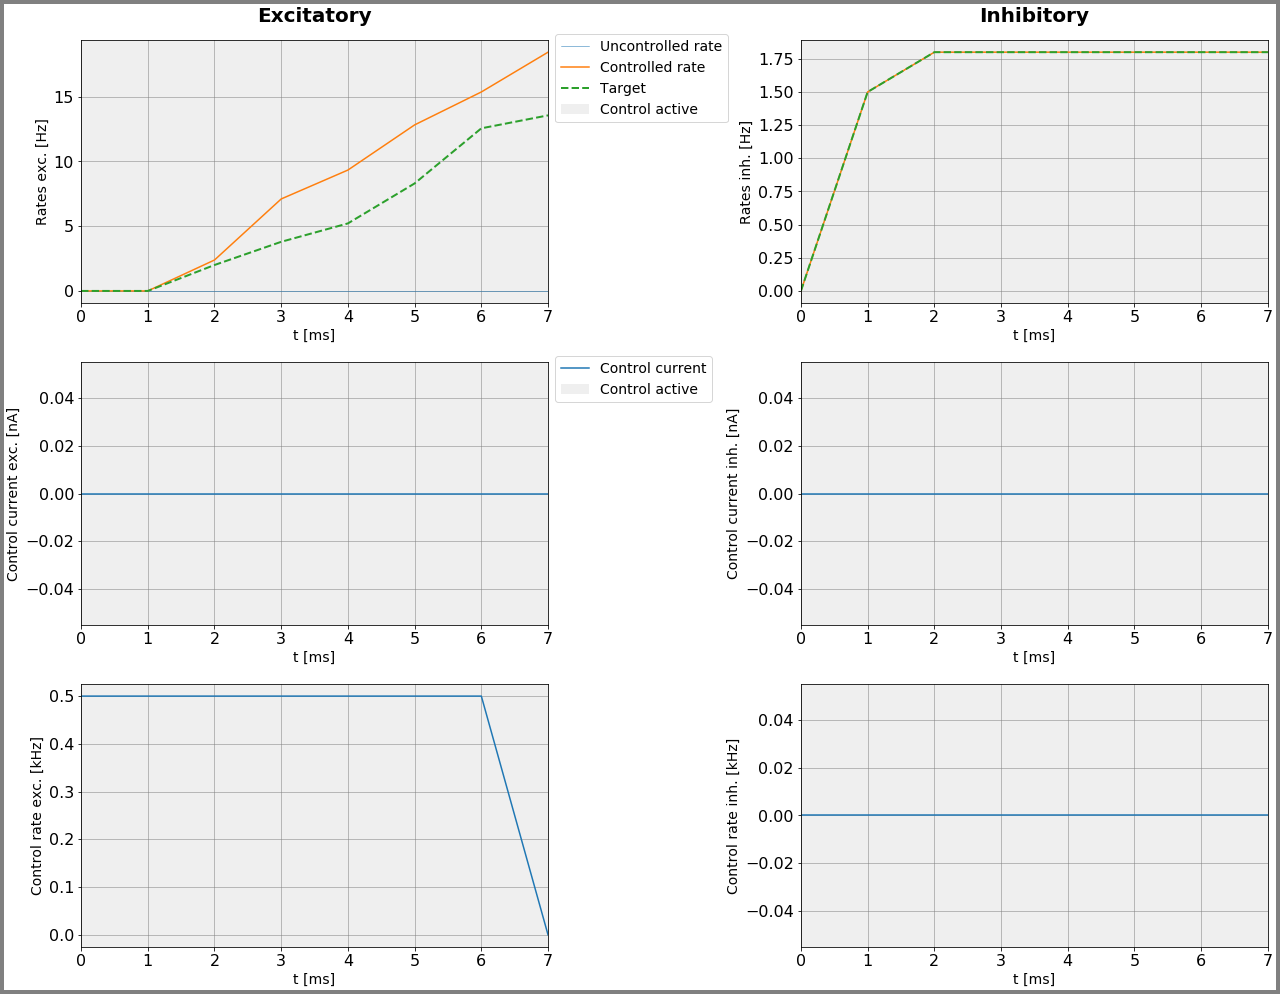

In [831]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

ValueError: x and y must have same first dimension, but have shapes (71,) and (8,)

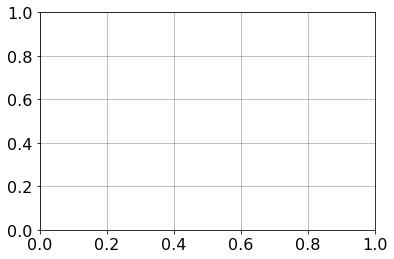

In [445]:
diff = control0 - bestControlA
#diff[0,2,-2:] = 0.

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [815]:
setinitvars(high_state_vars)
max_it = 100
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-8

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA_A2[:,:,:]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = [control_ind])

RUN  0 , total integrated cost:  85.2753467939098
RUN  1 , total integrated cost:  1.9234363882808188
RUN  2 , total integrated cost:  0.7893355076459304
RUN  3 , total integrated cost:  0.3736085506730884
RUN  4 , total integrated cost:  0.20292409732309563
RUN  5 , total integrated cost:  0.12467089974469873
RUN  6 , total integrated cost:  0.08690388778101679
RUN  7 , total integrated cost:  0.06661296832445499
RUN  8 , total integrated cost:  0.05621823530861709
RUN  9 , total integrated cost:  0.05041038705626462
RUN  10 , total integrated cost:  0.046623373289207216
RUN  11 , total integrated cost:  0.04403785845185608
RUN  12 , total integrated cost:  0.042077370067737166
RUN  13 , total integrated cost:  0.040544961263221185
RUN  14 , total integrated cost:  0.039230282040217244
RUN  15 , total integrated cost:  0.03815809773138519
RUN  16 , total integrated cost:  0.0371243626436367
RUN  17 , total integrated cost:  0.036225799209717004
RUN  18 , total integrated cost:  0.0353

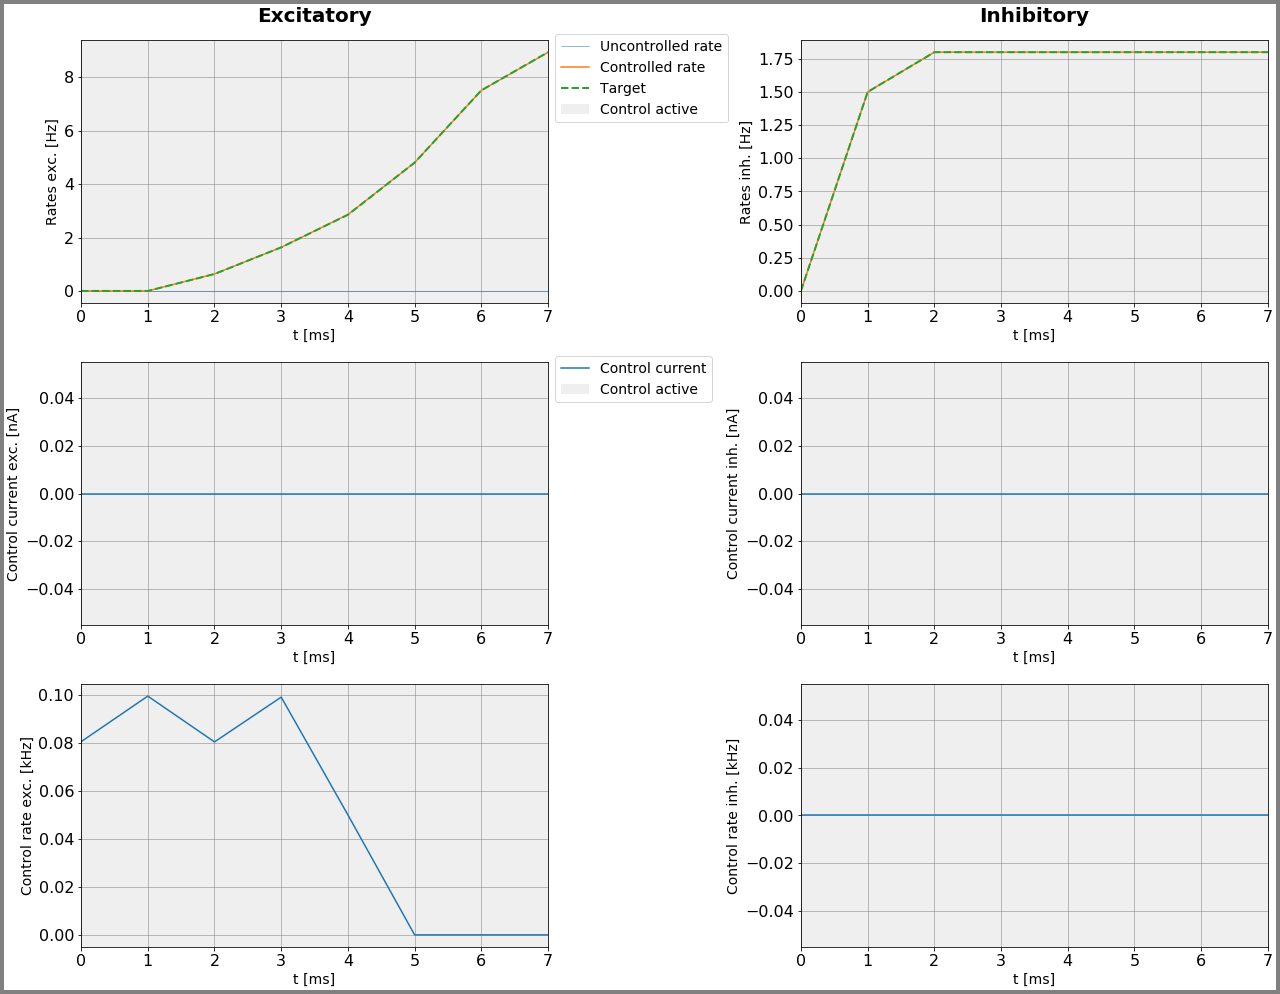

In [816]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

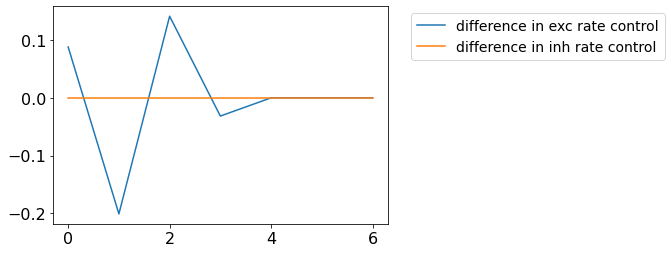

In [227]:
diff = control0 - bestControlA_A2
diff[0,2,-2:] = 0.

t = np.arange(0,dur+aln.params.dt, aln.params.dt)

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

-0.0004884455958080736


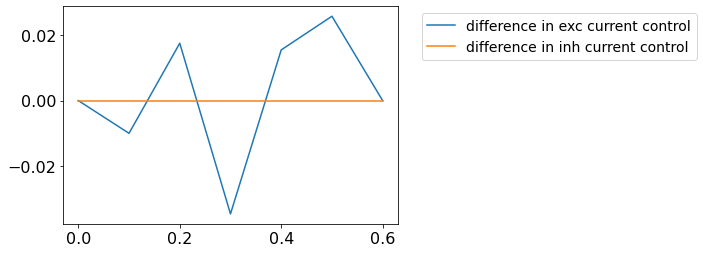

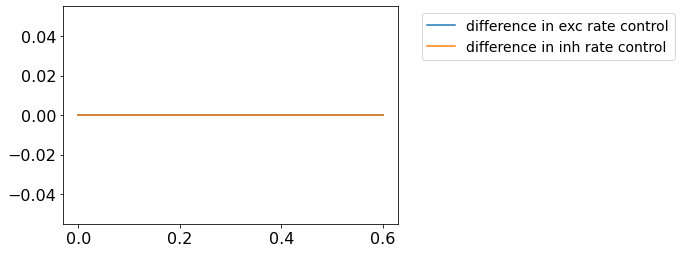

In [29]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

c_diff = costA_A2[6] - costA[3]
print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [748]:
np.sqrt(0.)

0.0